# Step 12: Other aggregation targets on SPY, QQQ, GLD and AGG

Companion to Lecture 3 of *Systematic Trading Notes*. Notebook 11 aggregated bars into a smoothed
**price**. This notebook aggregates them into five other quantities: volatility, trend strength,
order flow, the relationship between two assets, and the shape of the return distribution.

Three practical questions run through every section:

1. **Units.** Is the number comparable across assets and across decades, or only within one series?
2. **Memory.** Are window lengths chosen so that indicators which will be read together look back
   over comparable spans?
3. **Precision.** How much of a statistic's movement is real, and how much is sampling noise?

Every formula is computed by hand once for a real date and asserted equal to the library or
vectorised value. Each normalisation and estimator is one with a published basis; references are
listed at the end, given from memory and to be checked against the originals before citation.

The assets span four very different behaviours: a broad equity index (SPY, from 1993), a
technology index (QQQ, from 1999), gold (GLD, from 2004) and investment-grade bonds (AGG, from
2003).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from plotly.subplots import make_subplots
from scipy.stats import norm

from trading_models.data.ohlc import load_ohlc
from trading_models.momentum import average_true_range
from trading_models.plotting import MUTED, SERIES, apply_theme, save_figure
from trading_models.trend_following.data.schema import InstrumentPanel
from trading_models.trend_following.signals.baselines.trend_strength import adx, efficiency_ratio

apply_theme()
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
RAW = ROOT / "data" / "raw"
FIG = ROOT / "lectures" / "03-same-bars-different-questions" / "figures"
TICKERS = ["SPY", "QQQ", "GLD", "AGG"]


def weekly(x):
    # charts of multi-decade histories are drawn from weekly (Friday) values to keep this file small;
    # every statistic is still computed on daily data
    return x.resample("W-FRI").last()


## 1. Data

Adjusted OHLC from `trading_models.data.ohlc`, plus volume fetched into a separate cache (the
package loader does not fetch it). The cache file names are specific to this notebook's date range,
because `load_ohlc` checks a cache for the requested tickers, not the requested dates.

Adjusted prices are scaled by distribution and split factors. Dollar levels in the early part of an
adjusted series are therefore not prices that ever traded, whereas ratios within the same day (high
over low, close over open) are unaffected. This is one more reason to work in returns and ratios,
the subject of the next section.


In [2]:
ohlc = load_ohlc(TICKERS, start="1993-01-01", cache=RAW / "nb12_ohlc_long.csv")
vcache = RAW / "nb12_volume_long.csv"
if vcache.exists():
    volume = pd.read_csv(vcache, index_col=0, parse_dates=True)[TICKERS]
else:
    import yfinance as yf

    volume = yf.download(TICKERS, start="1993-01-01", auto_adjust=True, actions=False, progress=False)["Volume"][TICKERS]
    volume.to_csv(vcache)

O, H, L, C = (ohlc[k] for k in ("open", "high", "low", "close"))
for t in TICKERS:
    s = C[t].dropna()
    print(f"{t}: {s.index[0].date()} to {s.index[-1].date()}, {len(s)} bars")


SPY: 1993-01-29 to 2026-10-09, 8482 bars
QQQ: 1999-03-10 to 2026-10-09, 6940 bars
GLD: 2004-11-18 to 2026-10-09, 5507 bars
AGG: 2003-09-29 to 2026-10-09, 5795 bars


## 2. Units: why a dollar figure cannot be compared

Wilder's Average True Range (ATR) is measured in price units. A market that trades at 1,000 moves
more dollars per day than the same market at 100 with exactly the same risk, so a dollar ATR rises
with the price level even when nothing about risk has changed. Dividing by the price removes the
scale; the result, ATR as a percentage of the close, is often called *normalised ATR* (NATR) in
technical-analysis libraries. The table compares the first full year of each series with 2026.


In [3]:
atr14 = average_true_range(H, L, C, 14)
natr = atr14 / C
rows = {}
for t in TICKERS:
    a, n_ = atr14[t].dropna(), natr[t].dropna()
    first = a.index.year.min() + 1
    rows[t] = {
        "first year": first,
        "ATR, first year ($)": a[a.index.year == first].median(),
        "ATR, 2026 ($)": a[a.index.year == 2026].median(),
        "ATR % of price, first year": 100 * n_[n_.index.year == first].median(),
        "ATR % of price, 2026": 100 * n_[n_.index.year == 2026].median(),
    }
units = pd.DataFrame(rows).T
units["ratio, $"] = units["ATR, 2026 ($)"] / units["ATR, first year ($)"]
units["ratio, %"] = units["ATR % of price, 2026"] / units["ATR % of price, first year"]
units.round(3)


,first year,"ATR, first year ($)","ATR, 2026 ($)","ATR % of price, first year","ATR % of price, 2026","ratio, $","ratio, %"
SPY,1994.0,0.223,7.879,0.854,1.101,35.299,1.289
QQQ,2000.0,3.504,10.450,4.556,1.646,2.982,0.361
GLD,2005.0,0.405,7.984,0.936,2.011,19.698,2.149
AGG,2004.0,0.196,0.318,0.395,0.329,1.619,0.834


In dollars, SPY's ATR has grown about 35-fold since 1994, while as a percentage of price it is
almost unchanged. QQQ is the sharper case: in dollars it looks about three times *more* volatile
today than in 2000, while as a percentage of price it was nearly three times *more* volatile in
2000, during the collapse of the technology bubble. The dollar measure does not just exaggerate; it
gets the direction wrong.


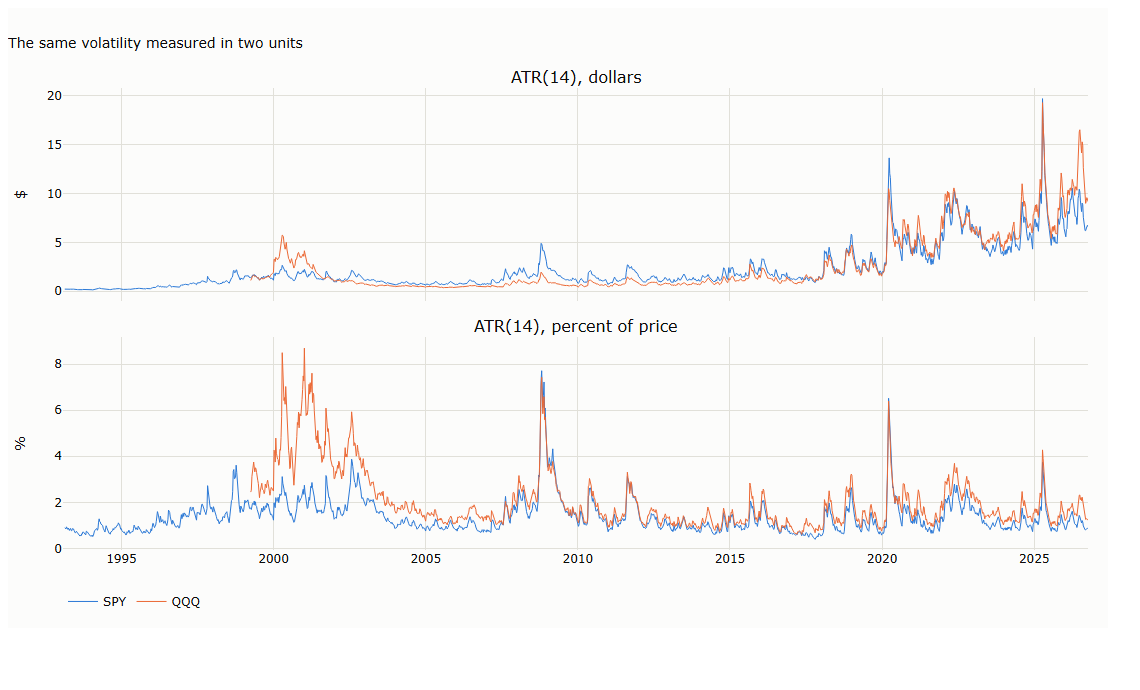

In [4]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                    subplot_titles=("ATR(14), dollars", "ATR(14), percent of price"))
for j, t in enumerate(["SPY", "QQQ"]):
    a_w, n_w = weekly(atr14[t]), weekly(natr[t])
    fig.add_scatter(x=a_w.index, y=a_w, name=t, mode="lines", line=dict(width=1, color=SERIES[j]), row=1, col=1)
    fig.add_scatter(x=n_w.index, y=100 * n_w, name=t, mode="lines", showlegend=False,
                    line=dict(width=1, color=SERIES[j]), row=2, col=1)
fig.update_yaxes(title_text="$", row=1, col=1)
fig.update_yaxes(title_text="%", row=2, col=1)
fig.update_layout(title="The same volatility measured in two units", height=620, width=1100,
                  margin=dict(t=80, b=70), legend=dict(orientation="h", y=-0.08, x=0))
save_figure(fig, "12_01_units", FIG)
fig


## 3. From a range to a volatility

ATR is a range measure, not a standard deviation. Ranges and standard deviations are linked by a
classical result: for a price following a random walk with daily volatility $\sigma$, the expected
high-low range of a day is $\sqrt{8/\pi}\,\sigma \approx 1.596\,\sigma$ (Feller, 1951). Parkinson (1980)
built a volatility estimator on the same idea, and later work refined it. With $h=\ln(H/L)$,
$c=\ln(C/O)$ and $o=\ln(O_t/C_{t-1})$:

| Estimator | Daily variance estimate | What it uses |
|---|---|---|
| Close-to-close | variance of $\ln(C_t/C_{t-1})$ | Closes only |
| Parkinson (1980) | $h^2 / (4\ln 2)$ | High and low |
| Garman–Klass (1980) | $\tfrac12 h^2 - (2\ln2-1)\,c^2$ | Open, high, low, close |
| Rogers–Satchell (1991) | $\ln\tfrac{H}{C}\ln\tfrac{H}{O} + \ln\tfrac{L}{C}\ln\tfrac{L}{O}$ | Same, robust to drift |
| Yang–Zhang (2000) | $\sigma_o^2 + k\,\sigma_c^2 + (1-k)\,\sigma_{RS}^2$ | Adds the overnight gap $o$ |

with $k = 0.34/\big(1.34 + (n+1)/(n-1)\big)$. The first four range-based estimators only see the
trading session; Yang–Zhang adds the variance of the overnight gap. ATR converted by Feller's
constant, $\text{ATR\%}/\sqrt{8/\pi}$, is included for comparison: true range catches part of the gap
through the previous close, but not all of it.

Two biases are documented in this literature: daily highs and lows recorded from discrete trades
understate the true extremes of a continuous path (Garman & Klass, 1980; Alizadeh, Brandt &
Diebold, 2002), and session-only estimators miss whatever happens overnight.


In [5]:
W = 27  # matched to Wilder's 14-bar smoothing; see section 4


def vol_estimators(t: str, window: int = W) -> pd.DataFrame:
    o, h, lw, c = O[t], H[t], L[t], C[t]
    hl, co, ov = np.log(h / lw), np.log(c / o), np.log(o / c.shift(1))
    rs = np.log(h / c) * np.log(h / o) + np.log(lw / c) * np.log(lw / o)
    k = 0.34 / (1.34 + (window + 1) / (window - 1))
    out = pd.DataFrame({
        "close-to-close": np.log(c).diff().rolling(window).std(),
        "Parkinson": np.sqrt((hl ** 2).rolling(window).mean() / (4 * np.log(2))),
        "Garman-Klass": np.sqrt((0.5 * hl ** 2 - (2 * np.log(2) - 1) * co ** 2).rolling(window).mean()),
        "Rogers-Satchell": np.sqrt(rs.rolling(window).mean()),
        "Yang-Zhang": np.sqrt(ov.rolling(window).var() + k * co.rolling(window).var() + (1 - k) * rs.rolling(window).mean()),
        "ATR% / sqrt(8/pi)": natr[t] / np.sqrt(8 / np.pi),
    })
    out.attrs["overnight_share"] = (ov.rolling(window).var() / out["Yang-Zhang"] ** 2).median()
    return out * np.sqrt(252)


est = {t: vol_estimators(t) for t in ["SPY", "GLD", "AGG"]}
summary = pd.DataFrame({t: 100 * e.dropna().median() for t, e in est.items()}).round(2)
ratio = pd.DataFrame({t: e.dropna().median() / e.dropna()["close-to-close"].median() for t, e in est.items()}).round(2)
print("Annualised volatility, median over each sample (%):")
display(summary)
print("Relative to close-to-close:")
display(ratio)
print("Median share of Yang-Zhang variance coming from the overnight gap:",
      {t: round(float(e.attrs['overnight_share']), 2) for t, e in est.items()})


Annualised volatility, median over each sample (%):


,SPY,GLD,AGG
close-to-close,13.31,14.73,3.56
Parkinson,11.28,9.91,2.90
Garman-Klass,11.42,9.99,2.92
Rogers-Satchell,11.42,10.00,2.96
Yang-Zhang,13.83,14.75,3.92
ATR% / sqrt(8/pi),11.69,11.94,3.25


Relative to close-to-close:


,SPY,GLD,AGG
close-to-close,1.00,1.00,1.00
Parkinson,0.85,0.67,0.81
Garman-Klass,0.86,0.68,0.82
Rogers-Satchell,0.86,0.68,0.83
Yang-Zhang,1.04,1.00,1.10
ATR% / sqrt(8/pi),0.88,0.81,0.91


Median share of Yang-Zhang variance coming from the overnight gap: {'SPY': 0.28, 'GLD': 0.53, 'AGG': 0.45}


The pattern is the one the literature predicts. The session-only estimators (Parkinson,
Garman–Klass, Rogers–Satchell) report 67–86% of close-to-close volatility; Yang–Zhang, which adds the
overnight gap back, reports 100–110%. The shortfall is largest for GLD: gold trades around the clock
while GLD trades only during US hours, so about half of its variance arrives while GLD is closed.

**Using ATR as a volatility measure, without improvising.** Two steps, both standard:
divide by price (section 2), then divide by $\sqrt{8/\pi}$ (Feller's range constant). The result is
in the same units as an annualised standard deviation. It runs at 81–91% of close-to-close
volatility here, for the documented reasons above, so it is reliable for *comparing* volatility
across assets and over time and for sizing positions in proportion to it (the use made of it in the
Turtle trading rules, Faith 2007); where the *level* must be accurate, Yang–Zhang is the estimator
built for that purpose.


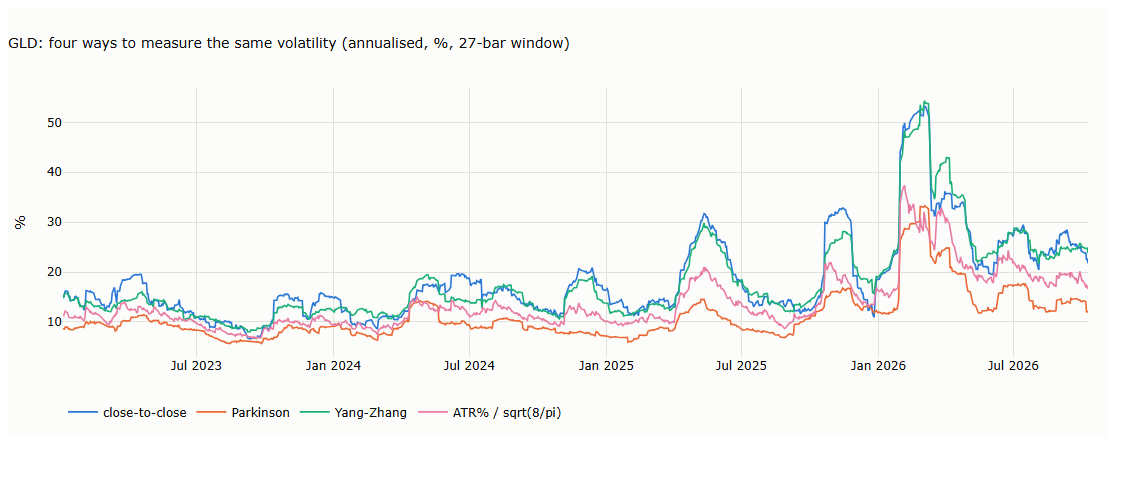

In [6]:
lo = "2023-01-01"
fig = go.Figure()
for j, col in enumerate(["close-to-close", "Parkinson", "Yang-Zhang", "ATR% / sqrt(8/pi)"]):
    s = 100 * est["GLD"][col].loc[lo:]
    fig.add_scatter(x=s.index, y=s, name=col, mode="lines", line=dict(width=1.6, color=SERIES[j]))
fig.update_layout(title="GLD: four ways to measure the same volatility (annualised, %, 27-bar window)",
                  yaxis_title="%", height=430, width=1100, margin=dict(t=80, b=70),
                  legend=dict(orientation="h", y=-0.15, x=0))
save_figure(fig, "12_02_vol_estimators", FIG)
fig


**By hand, one day.** True range on 16 March 2020, the largest one-day fall in SPY since 1987, and
one step of Wilder's recursion: $\mathrm{ATR}_t = \mathrm{ATR}_{t-1} + (\mathrm{TR}_t - \mathrm{ATR}_{t-1})/14$.


In [7]:
DAY = pd.Timestamp("2020-03-16")
t = "SPY"
i = C[t].index.get_loc(DAY)
h_, l_, c_prev = H[t].iloc[i], L[t].iloc[i], C[t].iloc[i - 1]
cands = {"H - L": h_ - l_, "|H - C(prev)|": abs(h_ - c_prev), "|L - C(prev)|": abs(l_ - c_prev)}
tr = max(cands.values())
hand = atr14[t].iloc[i - 1] + (tr - atr14[t].iloc[i - 1]) / 14
print(f"SPY {DAY.date()}: H={h_:.2f}, L={l_:.2f}, previous close={c_prev:.2f}")
for k_, v_ in cands.items():
    print(f"  {k_:15s} = {v_:.2f}")
print(f"  true range = {tr:.2f} (the gap from yesterday's close dominates)")
print(f"  ATR = {atr14[t].iloc[i - 1]:.4f} + ({tr:.2f} - {atr14[t].iloc[i - 1]:.4f}) / 14 = {hand:.4f};  library {atr14[t].iloc[i]:.4f}")
assert np.isclose(hand, atr14[t].iloc[i])
park = np.log(h_ / l_) ** 2 / (4 * np.log(2))
print(f"  Parkinson daily variance for this one day: ln(H/L)^2 / (4 ln 2) = {park:.6f}, "
      f"i.e. a daily volatility of {np.sqrt(park):.2%}")


SPY 2020-03-16: H=233.59, L=215.82, previous close=244.88
  H - L           = 17.77
  |H - C(prev)|   = 11.29
  |L - C(prev)|   = 29.06
  true range = 29.06 (the gap from yesterday's close dominates)
  ATR = 11.2315 + (29.06 - 11.2315) / 14 = 12.5050;  library 12.5050
  Parkinson daily variance for this one day: ln(H/L)^2 / (4 ln 2) = 0.002257, i.e. a daily volatility of 4.75%


## 4. Memory: choosing window lengths that belong together

Indicators read side by side should look back over comparable spans. Two standard summaries of a
smoother's memory (notebook 11, section 4) are the average age of the data it weights and its
variance reduction factor. A rolling window of $N$ bars has average age $(N-1)/2$; Wilder's
smoothing with period $n$ is an exponential average with $\alpha = 1/n$, whose average age is $n-1$.
Equating the two gives

$$
N = 2n - 1,
$$

so ATR(14) and ADX(14), both built on Wilder's smoothing, carry the memory of a **27-bar** rolling
window. That is why the volatility estimators above, and the efficiency ratio and order imbalance
below, use 27 bars. The defaults 14 and 20 have no common basis and should not be read together as
if they did.

Memory is not the only criterion. A statistic also needs enough observations to be estimated with
useful precision, and that requirement differs by statistic. For independent normal returns, the
standard errors are approximately

| Statistic | Standard error | At $N=27$ | At $N=63$ | At $N=252$ |
|---|---|---|---|---|
| Correlation (near 0) | $1/\sqrt{N}$ | 0.19 | 0.13 | 0.06 |
| Skewness | $\sqrt{6/N}$ | 0.47 | 0.31 | 0.15 |
| Excess kurtosis | $\sqrt{24/N}$ | 0.94 | 0.62 | 0.31 |

so correlation and the higher moments below use 63 bars (about one quarter): a 27-bar kurtosis would
carry a standard error close to 1 even before fat tails make it worse. These are choices made for a
stated reason, not defaults, and a different purpose could justify different ones.


In [8]:
n_wilder = 14
age_wilder = sum(k * (1 / n_wilder) * (1 - 1 / n_wilder) ** k for k in range(5000))
N_match = 2 * n_wilder - 1
print(f"Wilder({n_wilder}) average age: {age_wilder:.2f} bars; rolling window with the same age: N = {N_match} "
      f"(average age {(N_match - 1) / 2:.1f})")
se = pd.DataFrame({N_: {"correlation": 1 / np.sqrt(N_), "skewness": np.sqrt(6 / N_), "excess kurtosis": np.sqrt(24 / N_)}
                   for N_ in (27, 63, 252)}).round(2)
se


Wilder(14) average age: 13.00 bars; rolling window with the same age: N = 27 (average age 13.0)


,27,63,252
correlation,0.19,0.13,0.06
skewness,0.47,0.31,0.15
excess kurtosis,0.94,0.62,0.31


## 5. Trend strength: efficiency ratio and ADX

Both measure how one-sided recent movement has been, not its direction.

- **Efficiency ratio** (Kaufman): $|p_t-p_{t-N}| \,/\, \sum_{k=0}^{N-1}|p_{t-k}-p_{t-k-1}|$, in $[0,1]$.
- **ADX** (Wilder, 1978): from directional movements $+DM_t = H_t-H_{t-1}$ and $-DM_t = L_{t-1}-L_t$
  (each kept only if it is the larger of the two and positive), smoothed and divided by ATR to give
  $\pm DI$; then $DX = 100\,|{+DI}-{-DI}|/({+DI}+{-DI})$, smoothed again into ADX.

Both are imported from `trading_models`. ADX is reproduced below from its definition and checked
against the package on every bar, then one bar is stepped through by hand.


In [9]:
spy_panel = InstrumentPanel(close=C[["SPY"]].dropna(), high=H[["SPY"]].dropna(), low=L[["SPY"]].dropna())
er27 = efficiency_ratio(spy_panel, window=W)["SPY"]
adx14 = adx(spy_panel, period=14)["SPY"]

hs, ls_, cs = spy_panel.high["SPY"], spy_panel.low["SPY"], spy_panel.close["SPY"]
up, down = hs.diff(), -ls_.diff()
pdm = up.where((up > down) & (up > 0), 0.0)
mdm = down.where((down > up) & (down > 0), 0.0)
atr_s = average_true_range(hs.to_frame("SPY"), ls_.to_frame("SPY"), cs.to_frame("SPY"), 14)["SPY"]
pdi = 100 * pdm.ewm(alpha=1 / 14, adjust=False, min_periods=14).mean() / atr_s
mdi = 100 * mdm.ewm(alpha=1 / 14, adjust=False, min_periods=14).mean() / atr_s
dx = 100 * (pdi - mdi).abs() / (pdi + mdi)
adx_local = dx.ewm(alpha=1 / 14, adjust=False, min_periods=14).mean()
assert np.allclose(adx_local.dropna(), adx14.dropna())
print("ADX reproduced from its definition matches trading_models on all bars.")

j = cs.index.get_loc(DAY)
print(f"\n{DAY.date()}: up move {up.iloc[j]:+.2f}, down move {down.iloc[j]:+.2f} -> +DM {pdm.iloc[j]:.2f}, -DM {mdm.iloc[j]:.2f}")
print(f"  +DI {pdi.iloc[j]:.2f}, -DI {mdi.iloc[j]:.2f} -> DX = 100 x |{pdi.iloc[j]:.2f} - {mdi.iloc[j]:.2f}| / "
      f"({pdi.iloc[j]:.2f} + {mdi.iloc[j]:.2f}) = {dx.iloc[j]:.2f}")
hand = adx14.iloc[j - 1] + (dx.iloc[j] - adx14.iloc[j - 1]) / 14
print(f"  ADX = {adx14.iloc[j - 1]:.2f} + ({dx.iloc[j]:.2f} - {adx14.iloc[j - 1]:.2f}) / 14 = {hand:.2f};  library {adx14.iloc[j]:.2f}")
assert np.isclose(hand, adx14.iloc[j])
net, path = abs(cs.iloc[j] - cs.iloc[j - W]), cs.diff().abs().iloc[j - W + 1: j + 1].sum()
print(f"  Efficiency ratio(27): {net:.2f} / {path:.2f} = {net / path:.3f};  library {er27.iloc[j]:.3f}")
assert np.isclose(net / path, er27.iloc[j])


ADX reproduced from its definition matches trading_models on all bars.

2020-03-16: up move -13.26, down move +10.15 -> +DM 0.00, -DM 10.15
  +DI 9.66, -DI 38.82 -> DX = 100 x |9.66 - 38.82| / (9.66 + 38.82) = 60.16
  ADX = 41.10 + (60.16 - 41.10) / 14 = 42.46;  library 42.46
  Efficiency ratio(27): 84.57 / 210.67 = 0.401;  library 0.401


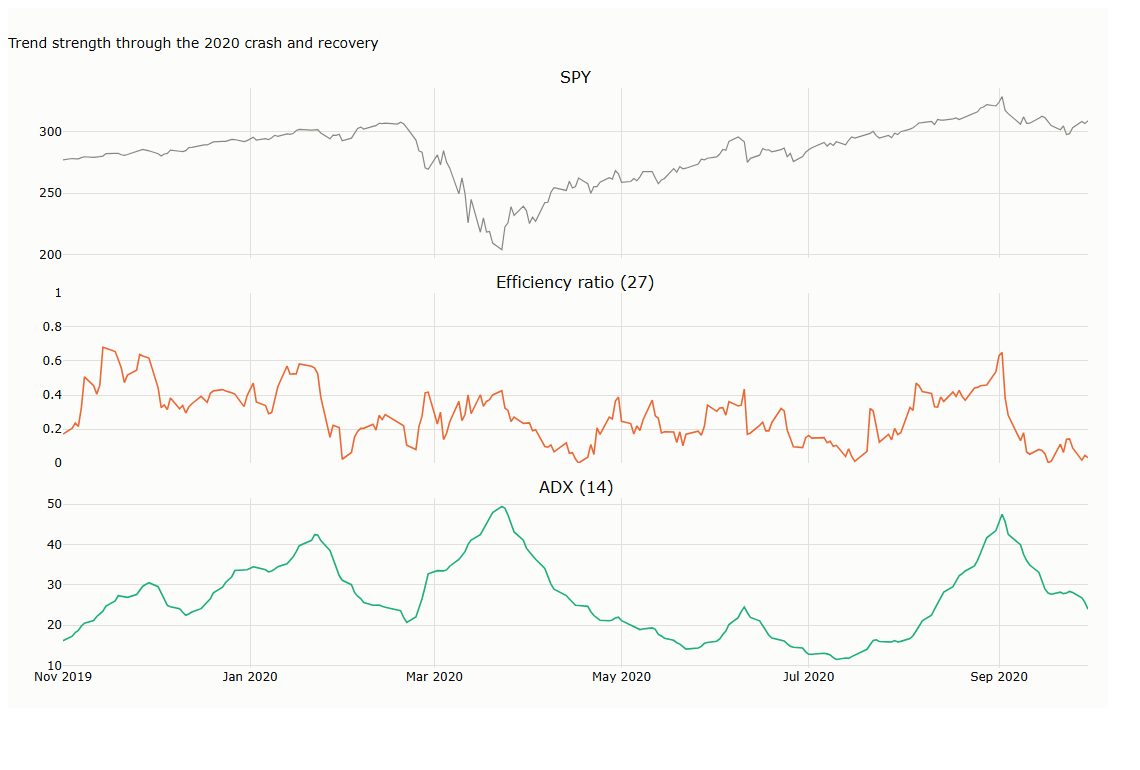

In [10]:
lo, hi = "2019-11-01", "2020-09-30"
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=("SPY", "Efficiency ratio (27)", "ADX (14)"))
fig.add_scatter(x=cs.loc[lo:hi].index, y=cs.loc[lo:hi], mode="lines", line=dict(width=1.2, color=MUTED), showlegend=False, row=1, col=1)
fig.add_scatter(x=er27.loc[lo:hi].index, y=er27.loc[lo:hi], mode="lines", line=dict(width=1.6, color=SERIES[1]), showlegend=False, row=2, col=1)
fig.add_scatter(x=adx14.loc[lo:hi].index, y=adx14.loc[lo:hi], mode="lines", line=dict(width=1.6, color=SERIES[2]), showlegend=False, row=3, col=1)
fig.update_yaxes(range=[0, 1], row=2, col=1)
fig.update_layout(title="Trend strength through the 2020 crash and recovery", height=700, width=1100, margin=dict(t=80))
save_figure(fig, "12_03_trend_strength", FIG)
fig


## 6. Order flow: from OBV to a comparable imbalance

On-balance volume (Granville, 1963) adds a bar's whole volume when its close is up and subtracts it
when its close is down, and accumulates the result without decay. Its level depends on the starting
date and on each asset's typical volume, so it cannot be compared across assets and its absolute
value carries no information; only changes in it do.

The literature on order flow gives a standard way to make it comparable. Buyer- and
seller-initiated volume over a window are summarised by **order imbalance**,
$(V_{buy}-V_{sell})/(V_{buy}+V_{sell}) \in [-1, 1]$ (Chordia, Roll & Subrahmanyam, 2002). OBV's
own rule, the sign of the close-to-close change, is a daily version of the *tick rule* used to
classify trades as buyer- or seller-initiated (Lee & Ready, 1991). Applying that classification
over a 27-bar window turns the change in OBV into an order imbalance:

$$
\mathrm{OIB}^{tick}_t = \frac{\sum_{k=0}^{N-1}\mathrm{sign}(\Delta C_{t-k})\,V_{t-k}}{\sum_{k=0}^{N-1}V_{t-k}}
= \frac{\mathrm{OBV}_t-\mathrm{OBV}_{t-N}}{\sum_{k=0}^{N-1}V_{t-k}}.
$$

The tick rule assigns the whole of a bar's volume to one side. **Bulk volume classification**
(Easley, López de Prado & O'Hara, 2012) splits it instead: the buyer-initiated fraction is
$\Phi(\Delta p/\sigma_{\Delta p})$, where $\Phi$ is the standard normal distribution function and
$\sigma_{\Delta p}$ is the standard deviation of price changes, so a small move splits volume almost
evenly and only a large move assigns most of it to one side. Here $\sigma$ is estimated from the
preceding 252 bars, so the classification uses no future data.


In [11]:
lr = np.log(C).diff()
sigma = lr.rolling(252).std().shift(1)
obv = (np.sign(lr).fillna(0.0) * volume).cumsum()
oib_tick = (np.sign(lr).fillna(0.0) * volume).rolling(W).sum() / volume.rolling(W).sum()
oib_bvc = ((2 * norm.cdf(lr / sigma) - 1) * volume).rolling(W).sum() / volume.rolling(W).sum()
oib_bvc = oib_bvc.where(sigma.notna())

t = "SPY"
k = oib_tick.index.get_loc(DAY)
sv = (np.sign(lr[t]) * volume[t]).iloc[k - W + 1: k + 1]
hand = sv.sum() / volume[t].iloc[k - W + 1: k + 1].sum()
print(f"Tick-rule imbalance, SPY, 27 bars to {DAY.date()}: signed volume {sv.sum():,.0f} / total {volume[t].iloc[k - W + 1: k + 1].sum():,.0f} = {hand:+.3f}")
assert np.isclose(hand, oib_tick[t].iloc[k])
obv_route = (obv[t].iloc[k] - obv[t].iloc[k - W]) / volume[t].iloc[k - W + 1: k + 1].sum()
print(f"  same number from OBV: (OBV_t - OBV_t-27) / total volume = {obv_route:+.3f}")
assert np.isclose(obv_route, hand)
z = lr[t].iloc[k] / sigma[t].iloc[k]
print(f"  BVC on {DAY.date()} alone: return {lr[t].iloc[k]:+.4f}, sigma {sigma[t].iloc[k]:.4f}, z = {z:+.2f}, "
      f"buyer fraction Phi(z) = {norm.cdf(z):.4f}")
print("\nCorrelation of the two imbalance measures:",
      {a: round(float(pd.concat([oib_tick[a], oib_bvc[a]], axis=1).dropna().corr().iloc[0, 1]), 2) for a in ["SPY", "GLD", "AGG"]})


Tick-rule imbalance, SPY, 27 bars to 2020-03-16: signed volume -2,251,280,200 / total 4,903,302,200 = -0.459
  same number from OBV: (OBV_t - OBV_t-27) / total volume = -0.459
  BVC on 2020-03-16 alone: return -0.1159, sigma 0.0145, z = -8.02, buyer fraction Phi(z) = 0.0000

Correlation of the two imbalance measures: {'SPY': 0.84, 'GLD': 0.89, 'AGG': 0.82}


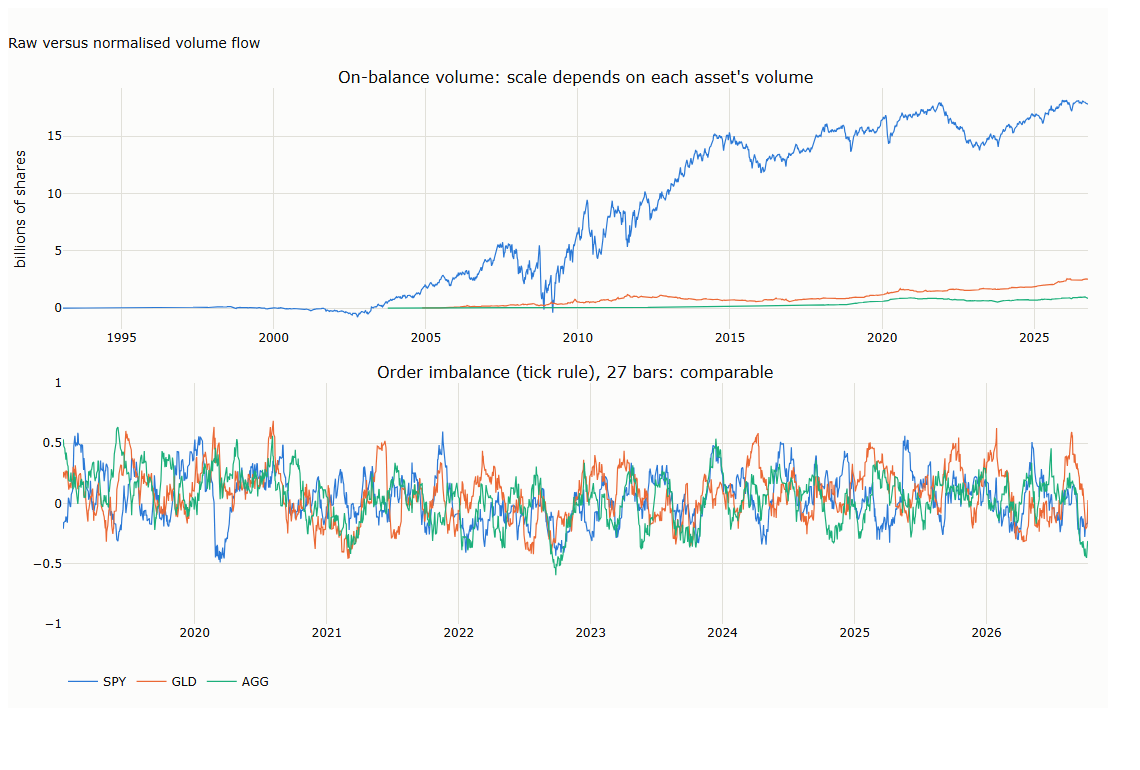

In [12]:
fig = make_subplots(rows=2, cols=1, vertical_spacing=0.1,
                    subplot_titles=("On-balance volume: scale depends on each asset's volume", "Order imbalance (tick rule), 27 bars: comparable"))
for j, a in enumerate(["SPY", "GLD", "AGG"]):
    ow = weekly(obv[a])
    fig.add_scatter(x=ow.index, y=ow / 1e9, name=a, mode="lines", line=dict(width=1.2, color=SERIES[j]), row=1, col=1)
    s = oib_tick[a].loc["2019-01-01":]
    fig.add_scatter(x=s.index, y=s, name=a, mode="lines", showlegend=False, line=dict(width=1.2, color=SERIES[j]), row=2, col=1)
fig.update_yaxes(title_text="billions of shares", row=1, col=1)
fig.update_yaxes(range=[-1, 1], row=2, col=1)
fig.update_layout(title="Raw versus normalised volume flow", height=700, width=1100, margin=dict(t=80, b=70),
                  legend=dict(orientation="h", y=-0.08, x=0))
save_figure(fig, "12_04_flow", FIG)
fig


## 7. Relationship between two assets: stocks and bonds

Rolling correlation and rolling beta of daily log returns, over 63 bars (section 4):

$$
\rho_t = \frac{\sum (x-\bar x)(y-\bar y)}{\sqrt{\sum (x-\bar x)^2 \sum (y-\bar y)^2}}, \qquad
\beta_t = \frac{\sum (x-\bar x)(y-\bar y)}{\sum (y-\bar y)^2}
$$

with $x$ = SPY and $y$ = AGG returns over the window. The stock–bond correlation is one of the most
consequential relationships in portfolio construction, and its sign has changed with the inflation
regime (Campbell, Pflueger & Viceira, 2020).

One caution from the literature: when volatility rises, measured correlation rises with it even if
the underlying dependence is unchanged (Forbes & Rigobon, 2002). A jump in rolling correlation during
a sell-off is therefore not, on its own, evidence that the relationship has changed.


In [13]:
CW = 63
rho = lr["SPY"].rolling(CW).corr(lr["AGG"])
beta = lr["SPY"].rolling(CW).cov(lr["AGG"]) / lr["AGG"].rolling(CW).var()

m = rho.index.get_loc(DAY)
x = lr["SPY"].iloc[m - CW + 1: m + 1]
y = lr["AGG"].iloc[m - CW + 1: m + 1]
dx_, dy_ = x - x.mean(), y - y.mean()
hand = (dx_ * dy_).sum() / np.sqrt((dx_ ** 2).sum() * (dy_ ** 2).sum())
print(f"Correlation, 63 bars to {DAY.date()}: {(dx_ * dy_).sum():.6f} / sqrt({(dx_ ** 2).sum():.6f} x {(dy_ ** 2).sum():.6f}) "
      f"= {hand:+.3f};  library {rho.iloc[m]:+.3f}")
assert np.isclose(hand, rho.iloc[m])

valid = rho.dropna()
print(f"\nShare of days with negative stock-bond correlation: 2004-2020 {(valid.loc['2004':'2020'] < 0).mean():.0%}, "
      f"2022 onward {(valid.loc['2022':] < 0).mean():.0%}")


Correlation, 63 bars to 2020-03-16: 0.002856 / sqrt(0.052762 x 0.002835) = +0.233;  library +0.233

Share of days with negative stock-bond correlation: 2004-2020 77%, 2022 onward 18%


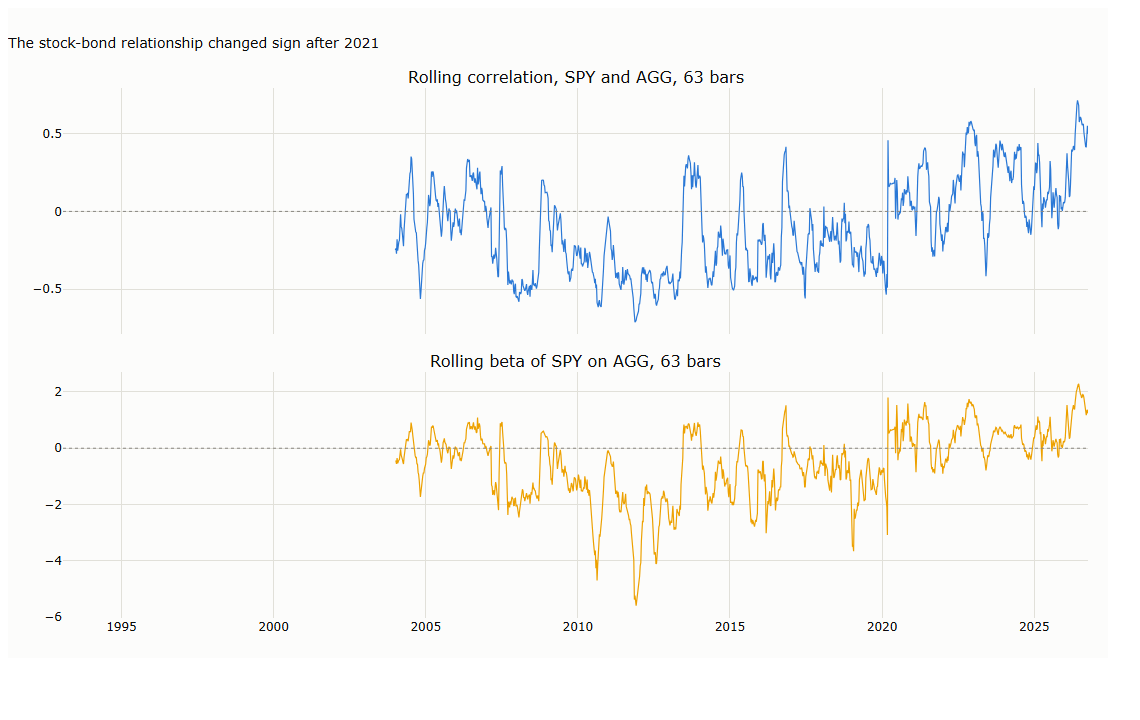

In [14]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.07,
                    subplot_titles=("Rolling correlation, SPY and AGG, 63 bars", "Rolling beta of SPY on AGG, 63 bars"))
rho_w, beta_w = weekly(rho), weekly(beta)
fig.add_scatter(x=rho_w.index, y=rho_w, mode="lines", line=dict(width=1.2, color=SERIES[0]), showlegend=False, row=1, col=1)
fig.add_scatter(x=beta_w.index, y=beta_w, mode="lines", line=dict(width=1.2, color=SERIES[4]), showlegend=False, row=2, col=1)
for r_ in (1, 2):
    fig.add_hline(y=0, line=dict(color=MUTED, width=1, dash="dot"), row=r_, col=1)
fig.update_layout(title="The stock-bond relationship changed sign after 2021", height=650, width=1100, margin=dict(t=80))
save_figure(fig, "12_05_stock_bond", FIG)
fig


## 8. Distribution shape over long histories

### 8.1 The estimators

`pandas` computes the adjusted Fisher–Pearson skewness and the corresponding bias-adjusted excess
kurtosis (Joanes & Gill, 1998). From the window's central moments $m_k = \frac1n\sum(x-\bar x)^k$:

$$
g_1 = \frac{m_3}{m_2^{3/2}},\quad G_1 = g_1\frac{\sqrt{n(n-1)}}{n-2};\qquad
g_2 = \frac{m_4}{m_2^{2}}-3,\quad G_2 = \frac{(n-1)\big((n+1)g_2+6\big)}{(n-2)(n-3)}.
$$


In [15]:
SW = 63
skew = lr[["SPY", "GLD", "AGG"]].rolling(SW).skew()
kurt = lr[["SPY", "GLD", "AGG"]].rolling(SW).kurt()

q = lr["SPY"].iloc[m - SW + 1: m + 1]
d_ = q - q.mean()
m2, m3, m4 = (d_ ** 2).mean(), (d_ ** 3).mean(), (d_ ** 4).mean()
n = SW
g1, g2 = m3 / m2 ** 1.5, m4 / m2 ** 2 - 3
G1 = g1 * np.sqrt(n * (n - 1)) / (n - 2)
G2 = (n - 1) * ((n + 1) * g2 + 6) / ((n - 2) * (n - 3))
print(f"SPY, 63 bars to {DAY.date()}: g1 = {g1:+.3f} -> G1 = {G1:+.3f} (library {skew['SPY'].iloc[m]:+.3f}); "
      f"g2 = {g2:+.3f} -> G2 = {G2:+.3f} (library {kurt['SPY'].iloc[m]:+.3f})")
assert np.isclose(G1, skew["SPY"].iloc[m]) and np.isclose(G2, kurt["SPY"].iloc[m])


SPY, 63 bars to 2020-03-16: g1 = -1.277 -> G1 = -1.309 (library -1.309); g2 = +5.136 -> G2 = +5.670 (library +5.670)


### 8.2 How much of the movement is noise: bootstrap bands

A rolling skewness or kurtosis wanders even if nothing about the market changes, simply because
each window is a small sample. A **bootstrap band** measures how far it would wander for that reason
alone. The idea (Efron, 1979): treat the full history of returns as the population, draw many
artificial windows of 63 returns from it, compute the statistic on each, and record the range that
holds 90% of the results. A rolling value outside that range is unlikely to be sampling noise.

How the artificial windows are drawn matters. Drawing returns one at a time at random (the *iid*
bootstrap) mixes calm days and crisis days inside every window. Drawing **blocks** of consecutive
returns (Künsch, 1989; Politis & Romano, 1994; here 21-day blocks) keeps each block's volatility
together, as in real windows. The comparison below shows why this matters for kurtosis
specifically.


In [16]:
rng = np.random.default_rng(7)
B, BLOCK = 3000, 21


def bands(x: np.ndarray) -> dict:
    iid_s, iid_k, blk_s, blk_k = [], [], [], []
    for _ in range(B):
        a = pd.Series(rng.choice(x, SW, replace=True))
        iid_s.append(a.skew()); iid_k.append(a.kurt())
        starts = rng.integers(0, len(x) - BLOCK, SW // BLOCK)
        b = pd.Series(np.concatenate([x[s_: s_ + BLOCK] for s_ in starts]))
        blk_s.append(b.skew()); blk_k.append(b.kurt())
    pct = lambda v: np.percentile(v, [5, 95])  # noqa: E731
    return {"skew, iid": pct(iid_s), "skew, block": pct(blk_s), "kurt, iid": pct(iid_k), "kurt, block": pct(blk_k)}


band = {a: bands(lr[a].dropna().to_numpy()) for a in ["SPY", "GLD", "AGG"]}
tbl = pd.DataFrame({a: {k_: f"[{v_[0]:+.2f}, {v_[1]:+.2f}]" for k_, v_ in b.items()} for a, b in band.items()})
tbl.loc["full-sample excess kurtosis"] = [f"{lr[a].kurt():.1f}" for a in ["SPY", "GLD", "AGG"]]
tbl.loc["median 63-bar excess kurtosis"] = [f"{kurt[a].median():.2f}" for a in ["SPY", "GLD", "AGG"]]
tbl


,SPY,GLD,AGG
"skew, iid","[-2.55, +1.88]","[-1.91, +0.96]","[-2.43, +2.38]"
"skew, block","[-1.15, +0.81]","[-1.52, +0.71]","[-1.21, +0.97]"
"kurt, iid","[+0.27, +17.34]","[-0.00, +11.19]","[-0.07, +20.29]"
"kurt, block","[-0.27, +5.86]","[-0.22, +7.48]","[-0.54, +6.41]"
full-sample excess kurtosis,11.4,6.6,54.0
median 63-bar excess kurtosis,0.75,0.80,0.23


The block band for kurtosis is much *narrower* than the iid band, and the median 63-bar kurtosis is
far below the full-sample value (for SPY about 0.8 against 11). Both have the same cause: a sample
that mixes low-volatility and high-volatility periods has fat tails even if each period on its own
does not. This is the mixture-of-distributions explanation of fat tails (Clark, 1973). Much of the
famous excess kurtosis of daily returns comes from volatility changing over time, not from each
individual period being fat-tailed. For judging a *rolling* statistic the block band is therefore
the relevant benchmark, because real 63-day windows keep their volatility together too.


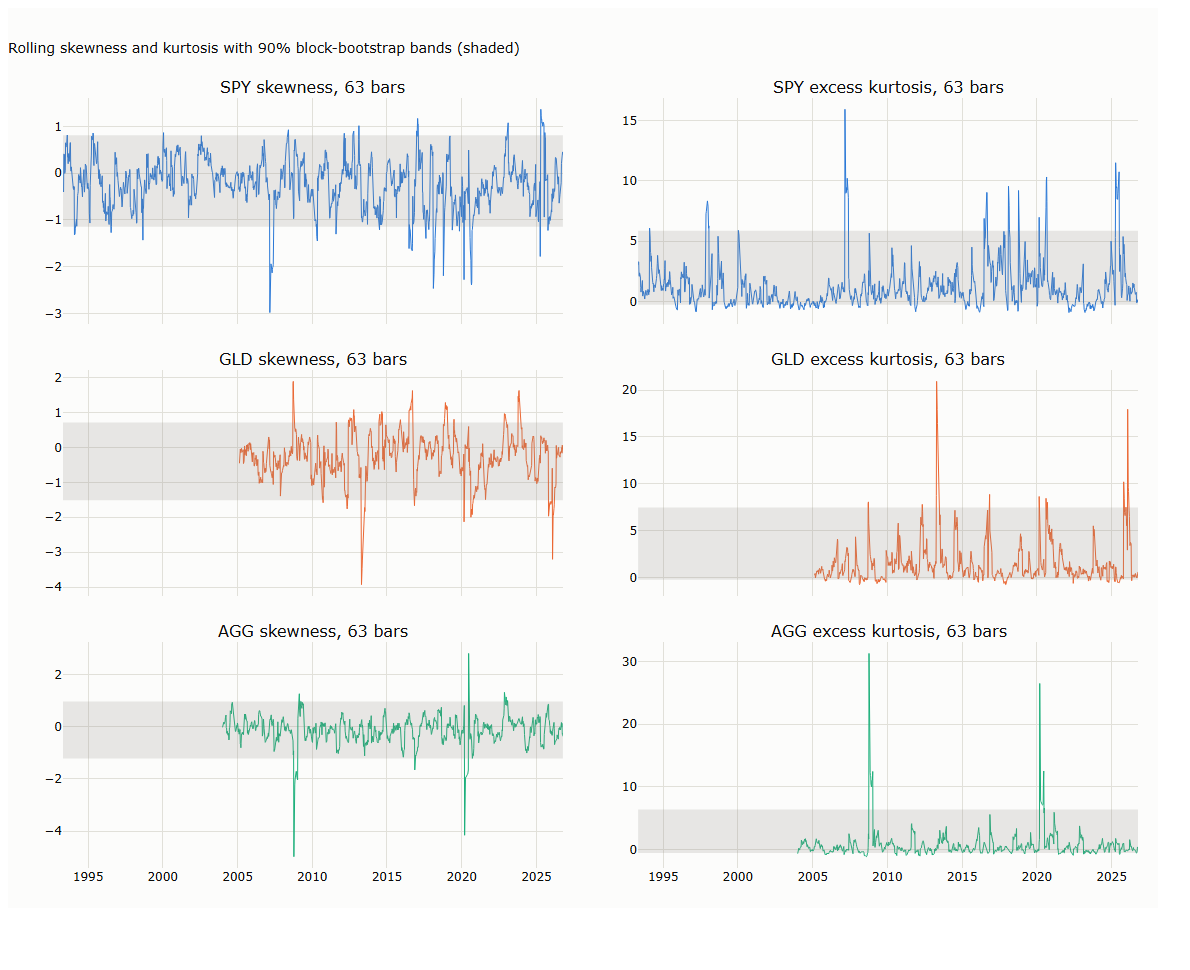

In [17]:
fig = make_subplots(rows=3, cols=2, shared_xaxes=True, vertical_spacing=0.06, horizontal_spacing=0.07,
                    subplot_titles=[f"{a} {s_}" for a in ["SPY", "GLD", "AGG"] for s_ in ("skewness, 63 bars", "excess kurtosis, 63 bars")])
for r_, a in enumerate(["SPY", "GLD", "AGG"], start=1):
    for c_, (stat, key) in enumerate([(skew, "skew, block"), (kurt, "kurt, block")], start=1):
        s = weekly(stat[a].dropna())
        fig.add_scatter(x=s.index, y=s, mode="lines", line=dict(width=1, color=SERIES[r_ - 1]), showlegend=False, row=r_, col=c_)
        lo_b, hi_b = band[a][key]
        fig.add_hrect(y0=lo_b, y1=hi_b, fillcolor=MUTED, opacity=0.18, line_width=0, row=r_, col=c_)
fig.update_layout(title="Rolling skewness and kurtosis with 90% block-bootstrap bands (shaded)",
                  height=900, width=1150, margin=dict(t=90))
save_figure(fig, "12_06_moments_bands", FIG)
fig


### 8.3 Do the higher moments cluster?

Rolling statistics computed from overlapping windows are autocorrelated by construction, so a
rolling chart cannot show clustering on its own. The test below uses **non-overlapping** 63-day
quarters: if a quarter with high kurtosis tends to be followed by another, the lag-1 autocorrelation
across quarters is positive. Its significance is judged against 2,000 random reorderings of the same
quarters (a permutation test). Volatility is shown alongside: its clustering is the best-documented
property of financial returns (Mandelbrot, 1963; Engle, 1982; Cont, 2001).


In [18]:
rows, tops = {}, {}
for a in ["SPY", "GLD", "AGG"]:
    r = lr[a].dropna()
    grp = r.groupby(np.arange(len(r)) // SW)
    full = grp.size() == SW
    qk, qv = grp.kurt()[full], grp.std()[full]
    ac_k, ac_v = qk.autocorr(1), qv.autocorr(1)
    null_k = np.array([pd.Series(rng.permutation(qk.to_numpy())).autocorr(1) for _ in range(2000)])
    null_v = np.array([pd.Series(rng.permutation(qv.to_numpy())).autocorr(1) for _ in range(2000)])
    rows[a] = {"quarters": len(qk), "volatility autocorr": round(ac_v, 2), "volatility p-value": round((np.abs(null_v) >= abs(ac_v)).mean(), 3),
               "kurtosis autocorr": round(ac_k, 2), "kurtosis p-value": round((np.abs(null_k) >= abs(ac_k)).mean(), 3)}
    top = qk.sort_values(ascending=False).head(3)
    tops[a] = [f"{r.index[int(g) * SW].date()} ({v_:.1f})" for g, v_ in top.items()]
display(pd.DataFrame(rows).T)
print("Highest-kurtosis quarters, by start date (excess kurtosis):")
display(pd.DataFrame(tops, index=["1st", "2nd", "3rd"]))


,quarters,volatility autocorr,volatility p-value,kurtosis autocorr,kurtosis p-value
SPY,134.0,0.48,0.000,0.15,0.062
GLD,87.0,0.60,0.000,0.15,0.140
AGG,91.0,0.39,0.002,0.27,0.012


Highest-kurtosis quarters, by start date (excess kurtosis):


,SPY,GLD,AGG
1st,2017-11-03 (16.5),2013-02-26 (13.3),2008-10-01 (11.1)
2nd,2007-02-02 (9.7),2025-12-03 (7.1),2020-01-07 (7.9)
3rd,2025-02-12 (8.5),2020-05-29 (7.0),2020-04-07 (7.5)


Volatility clusters strongly in all three assets. Kurtosis clusters only weakly: the autocorrelation
is small everywhere and distinguishable from chance only for AGG. For SPY the highest-kurtosis
quarters are not the crises but calm quarters interrupted by one large move: the top quarter ends on
5 February 2018 (a fall of 4.3%, with no other day in the quarter beyond 2.2%), and the second
contains 27 February 2007. In a prolonged crisis, volatility is high throughout the window, so no
single day stands out against it. AGG's top quarters, by contrast, are the 2008 and 2020 crises: in
an otherwise calm bond market, a few days of dislocation stand out sharply. Both cases fit the same
reading. **Rolling kurtosis measures surprise relative to recent volatility, not the level of
danger.**

### 8.4 Robust alternatives

Because sample skewness and kurtosis are driven by the few most extreme returns, quantile-based
measures are often used alongside them (Kim & White, 2004): Bowley's skewness
$(Q_3+Q_1-2Q_2)/(Q_3-Q_1)$ and Moors' kurtosis
$\big((E_7-E_5)+(E_3-E_1)\big)/(E_6-E_2) - 1.233$, where $Q_i$ are quartiles, $E_i$ octiles, and
$1.233$ is the normal-distribution value.


In [19]:
def bowley(x):
    q1, q2, q3 = np.percentile(x, [25, 50, 75])
    return (q3 + q1 - 2 * q2) / (q3 - q1)


def moors(x):
    e = np.percentile(x, [12.5, 25, 37.5, 62.5, 75, 87.5])
    return ((e[5] - e[3]) + (e[2] - e[0])) / (e[4] - e[1]) - 1.233


s = lr["SPY"].dropna()
mom = pd.DataFrame({"skewness": s.rolling(SW).skew(), "Bowley": s.rolling(SW).apply(bowley, raw=True),
                    "kurtosis": s.rolling(SW).kurt(), "Moors": s.rolling(SW).apply(moors, raw=True)}).dropna()
jump = (mom.diff() / mom.std()).abs()
out = pd.DataFrame({
    "largest 1-day change (own std)": jump.max(),
    "change on 2007-02-27": jump.loc["2007-02-27"],
    "change on 2018-02-05": jump.loc["2018-02-05"],
}).round(2)
print(f"Correlation: skewness with Bowley {mom['skewness'].corr(mom['Bowley']):+.2f}, kurtosis with Moors {mom['kurtosis'].corr(mom['Moors']):+.2f}")
out


Correlation: skewness with Bowley -0.02, kurtosis with Moors +0.13


,largest 1-day change (own std),change on 2007-02-27,change on 2018-02-05
skewness,6.61,4.84,3.80
Bowley,2.89,0.14,0.23
kurtosis,8.08,8.08,6.02
Moors,2.46,0.02,0.17


A single day can move the classical kurtosis by about eight times its own typical variation; the
quantile measures barely react to the same days. The two families are almost uncorrelated, because
they answer different questions: classical moments describe the most extreme returns in the window,
quantile measures describe the shape of the typical return. For tail-risk questions the classical
moments are the relevant ones, read against the bootstrap band; for the asymmetry of ordinary days,
the quantile measures are far more stable.

## 9. Practical notes

| Quantity | Units | Comparable across assets? | Window used here and why | Common mistake |
|---|---|---|---|---|
| ATR | Price | No | Wilder 14 (memory of 27 bars) | Comparing dollar ATR across assets or decades |
| ATR % of price, $/\sqrt{8/\pi}$ | Daily volatility | Yes | Same | Treating it as an unbiased volatility level (it reads about 10–20% low here) |
| Yang–Zhang | Volatility | Yes | 27 bars | Using session-only estimators on assets that move overnight |
| Efficiency ratio, ADX | Unitless | Yes | 27 / Wilder 14, memory-matched | Pairing a 14-bar ADX with a 10-bar efficiency ratio as if they were comparable |
| OBV | Shares, cumulative | No | — | Reading its level |
| Order imbalance | Unitless, $[-1,1]$ | Yes | 27 bars | Ignoring that the daily tick rule assigns all of a bar's volume to one side |
| Correlation, beta | Unitless | Yes | 63 bars (standard error) | Reading a crisis jump as a change in dependence (Forbes & Rigobon) |
| Skewness, kurtosis | Unitless | Yes | 63 bars (standard error) | Reading 20-bar values as precise; ignoring that one day can dominate |

Implementations of Wilder's smoothing differ in how the first value is seeded (Wilder used a simple
average of the first $n$ values; `trading_models` starts the recursion from the first value). The
two converge after a few dozen bars, but values at the very start of a series differ.

## 10. Summary

- **Units.** Dollar-denominated measures are not comparable across assets or time, and can point
  the wrong way (QQQ). Dividing by price fixes the scale; Feller's constant converts ATR into an
  annualised volatility; Yang–Zhang is the estimator built to get the level right including overnight
  moves.
- **Memory.** Wilder's period $n$ corresponds to a $2n-1$ bar rolling window; windows for statistics
  read together were matched on that basis, and windows for correlation and higher moments were set by
  their standard errors instead of by convention.
- **Precision.** Block-bootstrap bands show how much a rolling statistic moves by chance alone, and
  the mixture-of-distributions effect explains why the right band is the block band. Volatility
  clusters strongly; kurtosis barely does.
- **Comparability of flow.** OBV becomes a comparable quantity once it is expressed as an order
  imbalance; bulk volume classification is the published refinement of its all-or-nothing rule.

## References

- Alizadeh, S., Brandt, M. and Diebold, F. (2002). Range-based estimation of stochastic volatility models. *Journal of Finance.*
- Campbell, J., Pflueger, C. and Viceira, L. (2020). Macroeconomic drivers of bond and stock risks. *Journal of Political Economy.*
- Chordia, T., Roll, R. and Subrahmanyam, A. (2002). Order imbalance, liquidity, and market returns. *Journal of Financial Economics.*
- Clark, P. (1973). A subordinated stochastic process model with finite variance for speculative prices. *Econometrica.*
- Cont, R. (2001). Empirical properties of asset returns: stylized facts and statistical issues. *Quantitative Finance.*
- Easley, D., López de Prado, M. and O'Hara, M. (2012). Flow toxicity and liquidity in a high-frequency world. *Review of Financial Studies.*
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. *Annals of Statistics.*
- Engle, R. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica.*
- Faith, C. (2007). *Way of the Turtle.* McGraw-Hill.
- Feller, W. (1951). The asymptotic distribution of the range of sums of independent random variables. *Annals of Mathematical Statistics.*
- Forbes, K. and Rigobon, R. (2002). No contagion, only interdependence: measuring stock market comovements. *Journal of Finance.*
- Garman, M. and Klass, M. (1980). On the estimation of security price volatilities from historical data. *Journal of Business.*
- Granville, J. (1963). *Granville's New Key to Stock Market Profits.* Prentice-Hall.
- Joanes, D. and Gill, C. (1998). Comparing measures of sample skewness and kurtosis. *The Statistician.*
- Kim, T.-H. and White, H. (2004). On more robust estimation of skewness and kurtosis. *Finance Research Letters.*
- Künsch, H. (1989). The jackknife and the bootstrap for general stationary observations. *Annals of Statistics.*
- Lee, C. and Ready, M. (1991). Inferring trade direction from intraday data. *Journal of Finance.*
- Mandelbrot, B. (1963). The variation of certain speculative prices. *Journal of Business.*
- Parkinson, M. (1980). The extreme value method for estimating the variance of the rate of return. *Journal of Business.*
- Politis, D. and Romano, J. (1994). The stationary bootstrap. *Journal of the American Statistical Association.*
- Rogers, L. and Satchell, S. (1991). Estimating variance from high, low and closing prices. *Annals of Applied Probability.*
- Wilder, J.W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
- Yang, D. and Zhang, Q. (2000). Drift-independent volatility estimation based on high, low, open, and close prices. *Journal of Business.*
